<a href="https://colab.research.google.com/github/priyansh-commits/practice/blob/main/pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)


df.head()



import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()



In [ ]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])
cov=np.cov(df.iloc[:,0:3].T)
print(cov)
val,vector=np.linalg.eig(cov)
print(val)
print(vector[0:2])
pc=vector[0:2]
print(pc)
df_new=np.dot(df.iloc[:,0:3],pc.T)
print(df_new)
new_df=pd.DataFrame(df_new,columns=['PC1','PC2'])
new_df['target']=df['target'].values
new_df.head()

[[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]
[1.3536065  0.94557084 0.77774573]
[[-0.53875915 -0.69363291  0.47813384]
 [-0.65608325 -0.01057596 -0.75461442]]
[[-0.53875915 -0.69363291  0.47813384]
 [-0.65608325 -0.01057596 -0.75461442]]
[[ 0.59943321  1.79586208]
 [ 1.05691919 -0.2127375 ]
 [-0.27187555  0.49822203]
 [-0.62158585  0.02311035]
 [ 1.56728555  1.73096695]
 [-1.32015685 -0.25700249]
 [-0.47083382 -1.37312054]
 [-0.40154161  1.20306094]
 [-0.4337344   1.15332625]
 [ 0.22732643 -2.66984143]
 [ 1.00700656  0.59602187]
 [ 1.72611407  0.49251144]
 [-0.42938381  0.82926458]
 [ 0.88673295  0.52266372]
 [-0.87220495  0.53067521]
 [-3.36771525 -0.25462736]
 [ 0.68860521  0.65808377]
 [-0.47844383  0.77437194]
 [ 1.30454939  0.47664493]
 [-0.72904267 -0.84650569]
 [-0.06917835 -0.13099355]
 [ 0.48480244 -1.21770771]
 [ 1.05822124 -0.45202591]
 [ 0.7417154   1.02382203]
 [ 0.20277531  0.09181468]
 [-0.75789038 -2.422615

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [ ]:
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(new_df.iloc[:,0:2], new_df.iloc[:,2], test_size=0.2, random_state=42)

knn=KNeighborsClassifier(weights='distance',n_neighbors=3,algorithm='kd_tree',p=1.001)

knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
print(accuracy_score(y_test,y_pred))
#

0.75


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,0:3], df.iloc[:,3], test_size=0.2, random_state=42)

knn=KNeighborsClassifier(weights='distance',n_neighbors=3,algorithm='kd_tree',p=1.001)

knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.75


In [ ]:
df=pd.read_csv('/content/train.csv')
df.head()
df.describe()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:], df.iloc[:,0], test_size=0.2, random_state=42)

In [ ]:
X_train_new=scaler.fit_transform(X_train)
X_test_new=scaler.fit_transform(X_test)
x_train=pd.DataFrame(X_train_new,columns=X_train.columns)
x_test=pd.DataFrame(X_test_new,columns=X_test.columns)
x_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8400 entries, 0 to 8399
Columns: 784 entries, pixel0 to pixel783
dtypes: float64(784)
memory usage: 50.2 MB


In [ ]:
x_test.isna().sum().sum()

np.int64(0)

In [ ]:
# knn=KNeighborsClassifier(weights='distance',n_neighbors=3,algorithm='kd_tree',p=1.0001)

# knn.fit(x_train,y_train)
# y_pred=knn.predict(x_test)
# print(accuracy_score(y_test,y_pred))


In [ ]:
from sklearn.decomposition import PCA


pca = PCA(n_components=0.98)
X_train_trf = pca.fit_transform(x_train)
X_test_trf = pca.transform(x_test)

knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    algorithm='auto',
    p=1,
    n_jobs=-1
)
knn.fit(X_train_trf,y_train)
y_pred = knn.predict(X_test_trf)
print(accuracy_score(y_test,y_pred))

KeyboardInterrupt: 

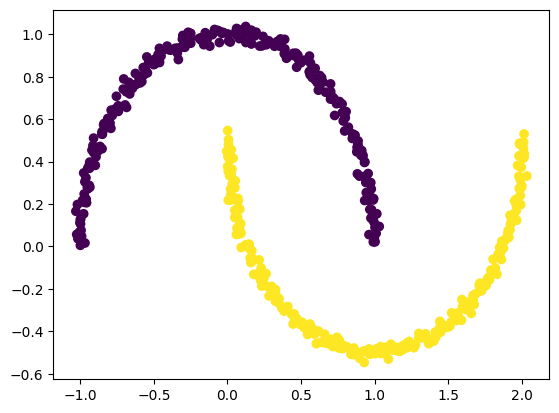

In [1]:
# kernal pca
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.02, random_state=417)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

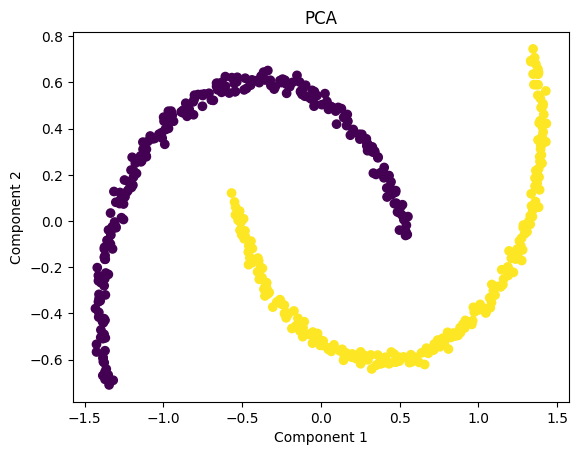

In [3]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.title("PCA")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

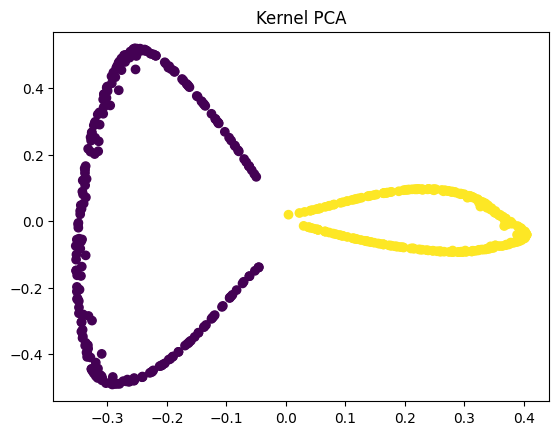

In [5]:
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(kernel='rbf', gamma=15)
X_kpca = kpca.fit_transform(X)

plt.title("Kernel PCA")
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y)
plt.show()